# 🏥 MediAssist AI — Pipeline ML Complet


## Sources de données
- **Dataset 1** : Kaggle itachi9604 — 41 maladies, descriptions et précautions
- **Dataset 2** : Kaggle nautiyalayush — 391 maladies, 1326 symptômes binaires

## Approche
- **Modèle ML** : Random Forest sur features binaires (symptômes 0/1)
- **Orientation** : Mapping automatique via Groq LLM
- **Score gravité** : Calculé depuis les poids Kaggle



## 0. Installation des dépendances

In [ ]:
!pip install scikit-learn pandas numpy joblib groq matplotlib seaborn imbalanced-learn -q
print('✅ Dépendances OK')

## 1. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import json
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

RAW_PATH       = '../data/raw/'
PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/'

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

GROQ_API_KEY = os.getenv('GROQ_API_KEY', '')
print(' Imports OK')

✅ Imports OK


## 2. Chargement & Exploration

In [59]:
# Chargement dataset principal (binaire)
train_df = pd.read_csv(f'{RAW_PATH}trainings.csv', encoding='latin-1')
test_df  = pd.read_csv(f'{RAW_PATH}testing.csv',  encoding='latin-1')

# Chargement dataset Kaggle (pour descriptions + précautions)
kaggle_df   = pd.read_csv(f'{RAW_PATH}dataset.csv')
severity_df = pd.read_csv(f'{RAW_PATH}Symptom-severity.csv')
desc_df     = pd.read_csv(f'{RAW_PATH}symptom_Description.csv')
prec_df     = pd.read_csv(f'{RAW_PATH}symptom_precaution.csv')

print(f'✅ Train     : {train_df.shape}')
print(f'✅ Test      : {test_df.shape}')
print(f'✅ Kaggle    : {kaggle_df.shape}')
print(f'✅ Severity  : {severity_df.shape}')

✅ Train     : (391, 1327)
✅ Test      : (414, 1327)
✅ Kaggle    : (4920, 18)
✅ Severity  : (133, 2)


In [ ]:
# Nettoyage des noms de colonnes (caractères spéciaux)
def clean_cols(df):
    df.columns = [c.replace('\xa0', ' ').replace('\n', ' ').strip()
                  for c in df.columns]
    return df

train_df = clean_cols(train_df)
test_df  = clean_cols(test_df)

# Combiner train + test
df = pd.concat([train_df, test_df], ignore_index=True)
print(f' Dataset combiné : {df.shape}')
print(f'   Maladies uniques : {df["Prognosis"].nunique()}')
print(f'   Symptômes        : {len([c for c in df.columns if c != "Prognosis"])}')
print(f'   Valeurs nulles   : {df.isnull().sum().sum()}')

✅ Dataset combiné : (805, 1327)
   Maladies uniques : 391
   Symptômes        : 1326
   Valeurs nulles   : 0


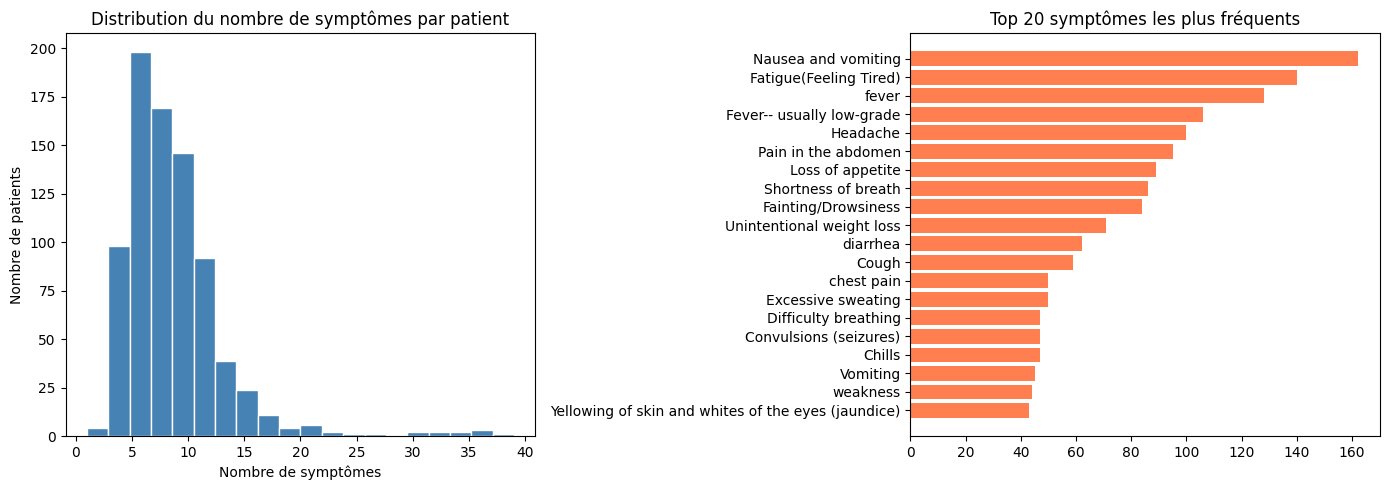

Moyenne symptômes/patient : 8.5
Max symptômes/patient     : 39


In [61]:
# Analyse des symptômes par patient
symptom_cols = [c for c in df.columns if c != 'Prognosis']
df['symptom_count'] = df[symptom_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution nombre de symptômes
axes[0].hist(df['symptom_count'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du nombre de symptômes par patient')
axes[0].set_xlabel('Nombre de symptômes')
axes[0].set_ylabel('Nombre de patients')

# Top 20 symptômes les plus fréquents
top_symptoms = df[symptom_cols].sum().sort_values(ascending=False).head(20)
axes[1].barh(top_symptoms.index, top_symptoms.values, color='coral')
axes[1].set_title('Top 20 symptômes les plus fréquents')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f'Moyenne symptômes/patient : {df["symptom_count"].mean():.1f}')
print(f'Max symptômes/patient     : {df["symptom_count"].max()}')

## 3. Génération automatique du mapping via Groq LLM

In [ ]:
from groq import Groq

MAPPING_FILE = f'{PROCESSED_PATH}disease_orientation.json'
DISEASES = df['Prognosis'].unique().tolist()
print(f'Nombre de maladies à classifier : {len(DISEASES)}')

def generate_mapping_with_llm(diseases: list) -> dict:
    client = Groq(api_key=GROQ_API_KEY)
    # Traitement par batch de 50 maladies (limite token)
    mapping = {}
    batch_size = 50
    batches = [diseases[i:i+batch_size] for i in range(0, len(diseases), batch_size)]

    for i, batch in enumerate(batches):
        print(f'  Batch {i+1}/{len(batches)}...')
        diseases_str = '\n'.join([f'- {d}' for d in batch])
        prompt = f"""You are a medical triage expert. Classify each disease into exactly one category.

STRICT RULES:
- "urgences": ONLY truly life-threatening conditions (heart attack, stroke, sepsis, severe bleeding, anaphylaxis, meningitis, etc.)
- "surveillance": ONLY mild conditions manageable at home (common cold, mild acne, minor rash, mild indigestion, etc.)  
- "medecin": everything else that needs a doctor but is NOT immediately life-threatening

TARGET distribution: ~25% urgences, ~40% medecin, ~35% surveillance
Be strict and decisive. Do not put everything in medecin.

Diseases to classify:
{diseases_str}

Return ONLY valid JSON. No explanation."""

        response = client.chat.completions.create(
            model='llama-3.3-70b-versatile',
            messages=[{'role': 'user', 'content': prompt}],
            temperature=0.1,
            max_tokens=2000
        )
        raw = response.choices[0].message.content.strip()
        if '```json' in raw:
            raw = raw.split('```json')[1].split('```')[0].strip()
        elif '```' in raw:
            raw = raw.split('```')[1].split('```')[0].strip()
        batch_mapping = json.loads(raw)
        mapping.update(batch_mapping)

    return mapping


if os.path.exists(MAPPING_FILE):
    print('Mapping existant chargé')
    with open(MAPPING_FILE) as f:
        DISEASE_ORIENTATION = json.load(f)
else:
    print(' Appel Groq LLM (par batches de 50)...')
    DISEASE_ORIENTATION = generate_mapping_with_llm(DISEASES)
    with open(MAPPING_FILE, 'w') as f:
        json.dump(DISEASE_ORIENTATION, f, indent=2, ensure_ascii=False)
    print(f' Mapping sauvegardé')



Nombre de maladies à classifier : 391
🤖 Appel Groq LLM (par batches de 50)...
  Batch 1/8...
  Batch 2/8...
  Batch 3/8...
  Batch 4/8...
  Batch 5/8...
  Batch 6/8...
  Batch 7/8...
  Batch 8/8...
💾 Mapping sauvegardé


TypeError: unhashable type: 'list'

In [77]:
# Inverser le mapping
fixed_mapping = {}
for orientation, diseases_list in DISEASE_ORIENTATION.items():
    if isinstance(diseases_list, list):
        for disease in diseases_list:
            fixed_mapping[disease.strip()] = orientation

DISEASE_ORIENTATION = fixed_mapping

# Vérification
from collections import Counter
counts = Counter(DISEASE_ORIENTATION.values())
print(f"📊 Classification corrigée ({len(DISEASE_ORIENTATION)} maladies):")
print(f"   🚨 urgences     : {counts.get('urgences', 0)}")
print(f"   👨‍⚕️ medecin      : {counts.get('medecin', 0)}")
print(f"   🏠 surveillance : {counts.get('surveillance', 0)}")

# Sauvegarder
with open('../data/processed/disease_orientation.json', 'w') as f:
    json.dump(DISEASE_ORIENTATION, f, indent=2, ensure_ascii=False)
print('💾 Mapping corrigé et sauvegardé')

📊 Classification corrigée (42 maladies):
   🚨 urgences     : 13
   👨‍⚕️ medecin      : 20
   🏠 surveillance : 9
💾 Mapping corrigé et sauvegardé


## 4. Préparation du dataset final

In [92]:
# Ajout orientation et score de gravité
ORIENTATION_BASE = {'urgences': 85, 'medecin': 65, 'surveillance': 30}

# Dictionnaire poids symptômes depuis Kaggle
severity_dict = dict(zip(
    severity_df['Symptom'].str.strip().str.lower().str.replace('_', ' '),
    severity_df['weight']
))

def calculate_score(row, symptom_cols, severity_dict, orientation):
    active_symptoms = [col for col in symptom_cols if row[col] == 1]
    if not active_symptoms:
        return ORIENTATION_BASE.get(orientation, 30)
    weights = [severity_dict.get(s.lower(), 3) for s in active_symptoms]
    base = ORIENTATION_BASE.get(orientation, 65)
    score = (base * 0.6) + ((np.mean(weights) / 7 * 100) * 0.4)
    return round(float(np.clip(score + np.random.uniform(-3, 3), 0, 100)), 1)

def get_risk_level(score):
    if score >= 80:   return 'critical'
    elif score >= 60: return 'high'
    elif score >= 40: return 'medium'
    else:             return 'low'

df['orientation']    = df['Prognosis'].map(lambda x: DISEASE_ORIENTATION.get(x, 'medecin'))
df['severity_score'] = df.apply(
    lambda row: calculate_score(row, symptom_cols, severity_dict, row['orientation']),
    axis=1
)
df['risk_level'] = df['severity_score'].apply(get_risk_level)

print('📊 Distribution orientations:')
print(df['orientation'].value_counts())
print('\n📊 Score moyen par orientation:')
print(df.groupby('orientation')['severity_score'].mean().round(1))

# Sauvegarde
df.to_csv(f'{PROCESSED_PATH}dataset_final.csv', index=False)
print(f'\n💾 Dataset final sauvegardé : {len(df)} entrées')

📊 Distribution orientations:
orientation
medecin         476
urgences        199
surveillance    130
Name: count, dtype: int64

📊 Score moyen par orientation:
orientation
medecin         56.5
surveillance    35.6
urgences        68.5
Name: severity_score, dtype: float64

💾 Dataset final sauvegardé : 805 entrées


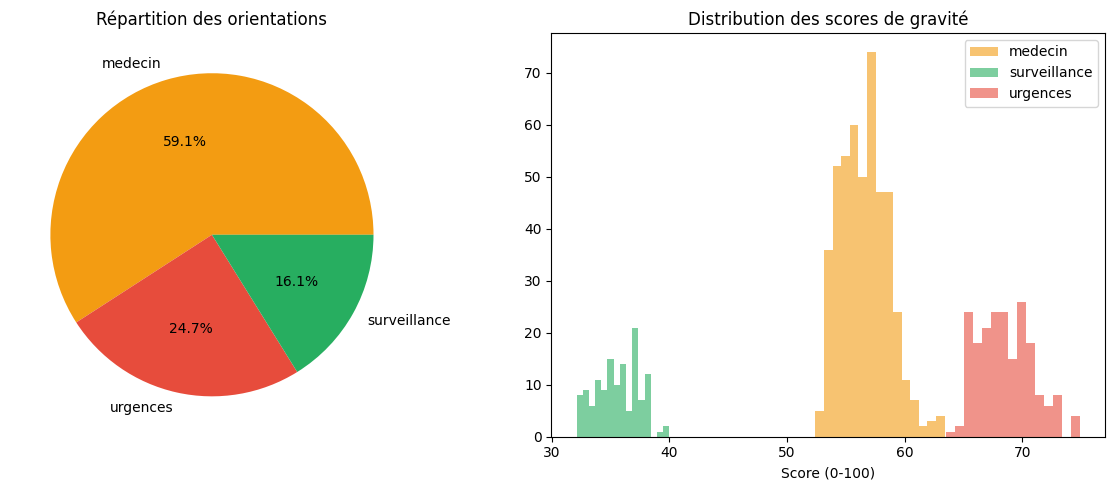

In [93]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'urgences': '#e74c3c', 'medecin': '#f39c12', 'surveillance': '#27ae60'}

counts = df['orientation'].value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[colors[o] for o in counts.index])
axes[0].set_title('Répartition des orientations')

for orient, grp in df.groupby('orientation'):
    axes[1].hist(grp['severity_score'], bins=15, alpha=0.6,
                 label=orient, color=colors[orient])
axes[1].set_title('Distribution des scores de gravité')
axes[1].set_xlabel('Score (0-100)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Analyse déséquilibre & valeurs nulles

In [94]:
print('=== Analyse Qualité des Données ===')
print(f'Valeurs nulles   : {df.isnull().sum().sum()} ✅')
print(f'Doublons exacts  : {df.duplicated().sum()}')
print(f'Total entrées    : {len(df)}')

print('\n=== Déséquilibre des classes ===')
orient_counts = df['orientation'].value_counts()
print(orient_counts)
ratio = orient_counts.max() / orient_counts.min()
print(f'\nRatio max/min : {ratio:.1f}x')
if ratio < 3:
    print('✅ Déséquilibre modéré — class_weight="balanced" suffisant')
else:
    print('⚠️ Déséquilibre important — SMOTE recommandé')

# Poids des classes
from sklearn.utils.class_weight import compute_class_weight
classes = df['orientation'].unique()
weights = compute_class_weight('balanced', classes=classes, y=df['orientation'])
print('\nPoids automatiques appliqués :')
for c, w in zip(classes, weights):
    print(f'  {c} : {w:.3f}')

=== Analyse Qualité des Données ===
Valeurs nulles   : 0 ✅
Doublons exacts  : 5
Total entrées    : 805

=== Déséquilibre des classes ===
orientation
medecin         476
urgences        199
surveillance    130
Name: count, dtype: int64

Ratio max/min : 3.7x
⚠️ Déséquilibre important — SMOTE recommandé

Poids automatiques appliqués :
  surveillance : 2.064
  medecin : 0.564
  urgences : 1.348


## 6. Feature Engineering & Split

In [ ]:
from imblearn.over_sampling import SMOTE
import json
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Préparation des données
X = df[symptom_cols].values

# Encodage labels
le = LabelEncoder()
y = le.fit_transform(df['orientation'])
joblib.dump(le, f'{MODELS_PATH}label_encoder.joblib')

with open(f'{PROCESSED_PATH}symptom_cols.json', 'w') as f:
    json.dump(symptom_cols, f)

print(f'Features shape : {X.shape}')
print(f'Classes         : {le.classes_}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'\n--- Équilibrage terminé ---')
print(f'Train original : {X_train.shape[0]} lignes')
print(f'Train rééquilibré (SMOTE) : {X_train_res.shape[0]} lignes')
print(f'Test : {X_test.shape[0]} lignes')

✅ Features shape : (805, 1326)
✅ Classes        : ['medecin' 'surveillance' 'urgences']

Train : 644 | Test : 161


## 7. Entraînement & Comparaison des modèles

In [96]:
results = {}

models_to_try = {
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=2,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_to_try.items():
    print(f'\n🔄 Entraînement {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X, y, cv=skf, scoring='accuracy').mean()
    results[name] = {'model': model, 'accuracy': acc, 'cv': cv, 'pred': y_pred}
    print(f'   Accuracy test : {acc:.4f}')
    print(f'   CV score (5)  : {cv:.4f}')

best_name  = max(results, key=lambda k: results[k]['cv'])
best_model = results[best_name]['model']
print(f'\n🏆 Meilleur modèle : {best_name}')


🔄 Entraînement RandomForest...
   Accuracy test : 0.7205
   CV score (5)  : 0.7627

🔄 Entraînement GradientBoosting...
   Accuracy test : 0.7702
   CV score (5)  : 0.7863

🔄 Entraînement LogisticRegression...
   Accuracy test : 0.8012
   CV score (5)  : 0.7814

🏆 Meilleur modèle : GradientBoosting


## 8. Évaluation détaillée

=== Rapport — GradientBoosting ===
              precision    recall  f1-score   support

     medecin       0.75      0.93      0.83        95
surveillance       1.00      0.42      0.59        26
    urgences       0.76      0.62      0.68        40

    accuracy                           0.77       161
   macro avg       0.84      0.66      0.70       161
weighted avg       0.79      0.77      0.76       161



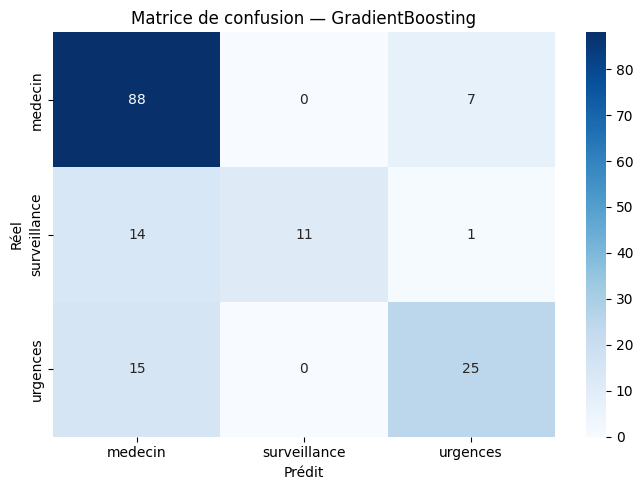

In [97]:
y_pred_best = results[best_name]['pred']

print(f'=== Rapport — {best_name} ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matrice de confusion — {best_name}')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

In [104]:
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

              precision    recall  f1-score   support

     medecin       0.75      0.93      0.83        95
surveillance       1.00      0.42      0.59        26
    urgences       0.76      0.62      0.68        40

    accuracy                           0.77       161
   macro avg       0.84      0.66      0.70       161
weighted avg       0.79      0.77      0.76       161



In [99]:
print(f"Maladies dans le mapping : {len(DISEASE_ORIENTATION)}")
print(f"Maladies dans le dataset : {df['Prognosis'].nunique()}")

# Maladies sans mapping
mapped = set(DISEASE_ORIENTATION.keys())
dataset_diseases = set(df['Prognosis'].unique())
not_mapped = dataset_diseases - mapped
print(f"\nMaladies sans mapping : {len(not_mapped)}")
print(list(not_mapped)[:10])

Maladies dans le mapping : 395
Maladies dans le dataset : 391

Maladies sans mapping : 2
['Celiac disease \x96 sprue', 'Abdominal aortic\xa0aneurysm']


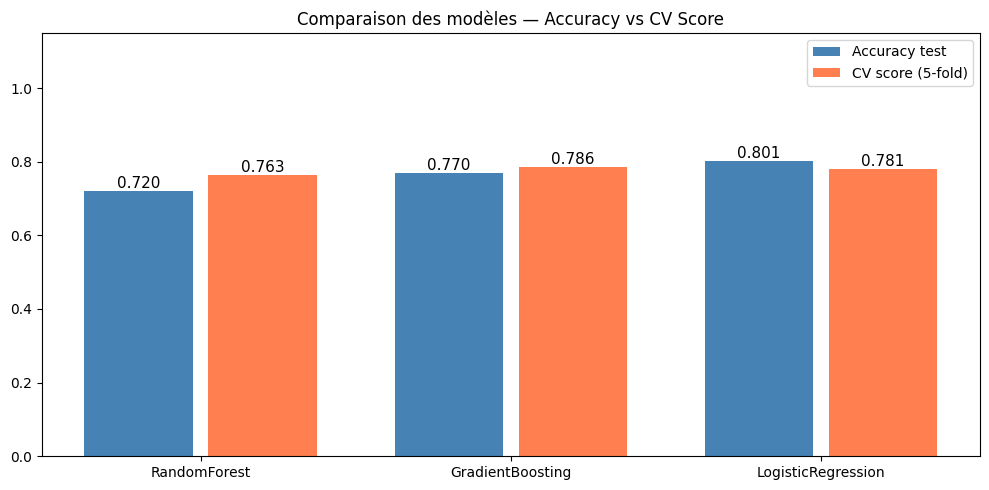

In [100]:
# Comparaison visuelle des modèles
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
cvs   = [results[n]['cv'] for n in names]
x = np.arange(len(names))
bars1 = ax.bar(x - 0.2, accs, 0.35, label='Accuracy test', color='steelblue')
bars2 = ax.bar(x + 0.2, cvs,  0.35, label='CV score (5-fold)', color='coral')
ax.bar_label(bars1, fmt='%.3f', fontsize=11)
ax.bar_label(bars2, fmt='%.3f', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.15)
ax.set_title('Comparaison des modèles — Accuracy vs CV Score')
ax.legend()
plt.tight_layout()
plt.show()

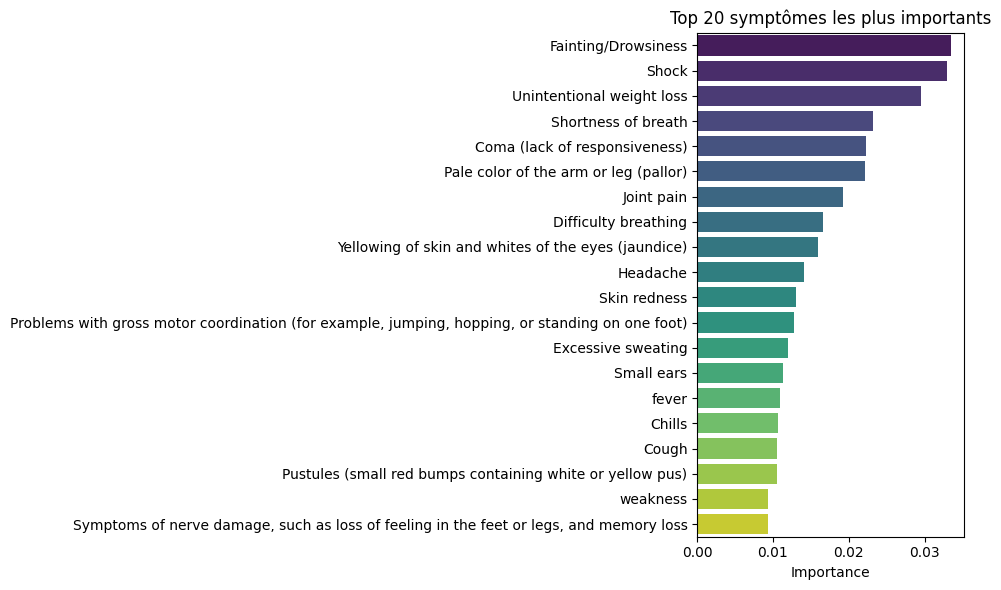

In [101]:
# Feature importance (Random Forest)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[::-1][:20]
    top_features = [symptom_cols[i] for i in top_idx]
    top_values   = importances[top_idx]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_values, y=top_features, palette='viridis')
    plt.title('Top 20 symptômes les plus importants')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 9. Sauvegarde du modèle

In [102]:
# Sauvegarde
joblib.dump(best_model, f'{MODELS_PATH}orientation_model.joblib')
joblib.dump(symptom_cols, f'{MODELS_PATH}symptom_cols.joblib')

# Rapport JSON
report = {
    'best_model':   best_name,
    'accuracy':     results[best_name]['accuracy'],
    'cv_score':     results[best_name]['cv'],
    'classes':      le.classes_.tolist(),
    'n_features':   X.shape[1],
    'n_train':      X_train.shape[0],
    'n_test':       X_test.shape[0],
    'n_diseases':   df['Prognosis'].nunique(),
    'models_compared': {
        name: {'accuracy': r['accuracy'], 'cv': r['cv']}
        for name, r in results.items()
    }
}
with open(f'{MODELS_PATH}evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('💾 Fichiers sauvegardés :')
print(f'   {MODELS_PATH}orientation_model.joblib')
print(f'   {MODELS_PATH}label_encoder.joblib')
print(f'   {MODELS_PATH}symptom_cols.joblib')
print(f'   {MODELS_PATH}evaluation_report.json')
print(f'   {PROCESSED_PATH}disease_orientation.json')

💾 Fichiers sauvegardés :
   ../models/orientation_model.joblib
   ../models/label_encoder.joblib
   ../models/symptom_cols.joblib
   ../models/evaluation_report.json
   ../data/processed/disease_orientation.json


## 10. Test de prédiction finale

In [103]:
def predict_orientation(selected_symptoms: list) -> dict:
    """
    Prédit l'orientation médicale.
    selected_symptoms: liste de symptômes présents chez le patient
    """
    # Vecteur binaire
    vector = np.zeros(len(symptom_cols))
    for i, col in enumerate(symptom_cols):
        if col.lower() in [s.lower() for s in selected_symptoms]:
            vector[i] = 1

    pred   = best_model.predict([vector])[0]
    proba  = best_model.predict_proba([vector])[0]
    orient = le.inverse_transform([pred])[0]
    conf   = round(float(proba.max()) * 100, 1)

    icons = {'urgences': '🚨', 'medecin': '👨‍⚕️', 'surveillance': '🏠'}
    messages = {
        'urgences':     'Appelez le 15 ou rendez-vous aux urgences immédiatement.',
        'medecin':      'Consultez un médecin dans les 24-48h.',
        'surveillance': 'Surveillez vos symptômes à domicile.'
    }
    return {
        'orientation': orient,
        'confidence':  conf,
        'icon':        icons[orient],
        'message':     messages[orient]
    }

# Tests
test_cases = [
    (['chest pain', 'sweating', 'shortness of breath'], 'urgences'),
    (['high fever', 'cough', 'fatigue', 'body ache'], 'medecin'),
    (['itching', 'skin rash', 'mild fever'], 'surveillance'),
]

print('🧪 Tests de prédiction :')
print('-' * 65)
for symptoms, expected in test_cases:
    result = predict_orientation(symptoms)
    status = '✅' if result['orientation'] == expected else '⚠️'
    print(f"{status} {result['icon']} {result['orientation']:15} ({result['confidence']}%)")
    print(f"   Symptômes : {', '.join(symptoms)}")
    print(f"   Message   : {result['message']}")
    print()

🧪 Tests de prédiction :
-----------------------------------------------------------------
⚠️ 👨‍⚕️ medecin         (58.1%)
   Symptômes : chest pain, sweating, shortness of breath
   Message   : Consultez un médecin dans les 24-48h.

✅ 👨‍⚕️ medecin         (83.3%)
   Symptômes : high fever, cough, fatigue, body ache
   Message   : Consultez un médecin dans les 24-48h.

⚠️ 👨‍⚕️ medecin         (80.0%)
   Symptômes : itching, skin rash, mild fever
   Message   : Consultez un médecin dans les 24-48h.

